# Day 67: ROC Curve & AUC Score

## Objective
- Understand what a ROC curve shows (TPR vs FPR)
- Read an AUC score correctly
- Compare models on one chart
- Know when Precision-Recall is the better choice

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

## Theory
- A classifier gives a **probability**; we pick a **threshold** (like 0.5) to turn it into a class
- **TPR** (True Positive Rate) = real positives we caught
- **FPR** (False Positive Rate) = real negatives we wrongly flagged
- **ROC curve** = TPR vs FPR at *every* threshold
- **AUC** = area under that curve
  - 0.5 = random guessing, 1.0 = perfect, 0.7+ = generally useful
- **Precision-Recall curve** is better when positives are rare (imbalanced data)

In [2]:
# Load football match data
df = pd.read_csv("dataset.csv")
print(df.shape)
print("Win rate:", round(df["won_match"].mean(), 3))

(800, 8)
Win rate: 0.58


In [3]:
# Features and target (did the team win?)
features = ["shots_on_target", "possession_pct", "pass_accuracy", "fouls", "home_game"]
X = df[features]
y = df["won_match"]

# Split the data (stratify keeps the win rate the same in both parts)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## Example 1: Get probabilities, then the ROC curve

In [4]:
# Train a simple model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# ROC needs probabilities, NOT 0/1 predictions
probs = log_reg.predict_proba(X_test)[:, 1]
print(probs[:5].round(2))

[0.5  0.89 0.34 0.63 0.65]


In [5]:
# roc_curve returns FPR, TPR and the thresholds it tried
fpr, tpr, thresholds = roc_curve(y_test, probs)
table = pd.DataFrame({"threshold": thresholds, "fpr": fpr, "tpr": tpr})
print(table.iloc[1:5].round(2))

   threshold   fpr   tpr
1       0.99  0.00  0.01
2       0.93  0.00  0.06
3       0.93  0.01  0.06
4       0.90  0.01  0.10


## Example 2: AUC score and the random baseline

In [6]:
# AUC = one number that summarises the whole curve
auc = roc_auc_score(y_test, probs)
print("Logistic AUC:", round(auc, 3))

# A model that guesses randomly should land near 0.5
rng = np.random.default_rng(0)
random_scores = rng.random(len(y_test))
print("Random AUC:", round(roc_auc_score(y_test, random_scores), 3))

Logistic AUC: 0.755
Random AUC: 0.481


## Example 3: Compare two models on one chart

Logistic Regression AUC: 0.755
Random Forest AUC: 0.742


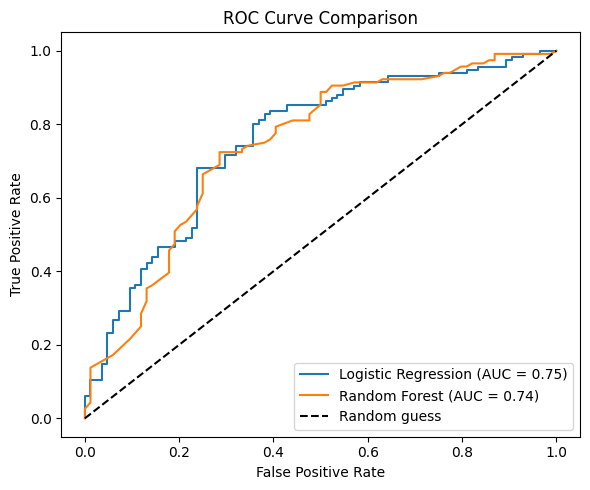

In [7]:
# Second model: Random Forest
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

models = {"Logistic Regression": log_reg, "Random Forest": forest}

plt.figure(figsize=(6, 5))
for name, model in models.items():
    p = model.predict_proba(X_test)[:, 1]
    f, t, _ = roc_curve(y_test, p)
    plt.plot(f, t, label=f"{name} (AUC = {roc_auc_score(y_test, p):.2f})")
    print(name, "AUC:", round(roc_auc_score(y_test, p), 3))

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_curve_comparison.png", dpi=150)
plt.show()

## Example 4: Imbalanced data and the Precision-Recall curve

In [8]:
# New target: red cards are RARE
y2 = df["red_card"]
print("Red card rate:", round(y2.mean(), 3))

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.25, random_state=42, stratify=y2
)
model2 = LogisticRegression(max_iter=1000).fit(X2_train, y2_train)
probs2 = model2.predict_proba(X2_test)[:, 1]

Red card rate: 0.109


In [9]:
# Precision-Recall curve values
precision, recall, pr_thresholds = precision_recall_curve(y2_test, probs2)
print("Points on the curve:", len(precision))

# Average Precision = area under the PR curve
ap = average_precision_score(y2_test, probs2)
print("Average Precision:", round(ap, 3))

Points on the curve: 201
Average Precision: 0.264


In [10]:
# Compare the two views of the same model
print("ROC AUC:          ", round(roc_auc_score(y2_test, probs2), 3))
print("Average Precision:", round(ap, 3))
print("Random AP baseline:", round(y2_test.mean(), 3))

ROC AUC:           0.743
Average Precision: 0.264
Random AP baseline: 0.11


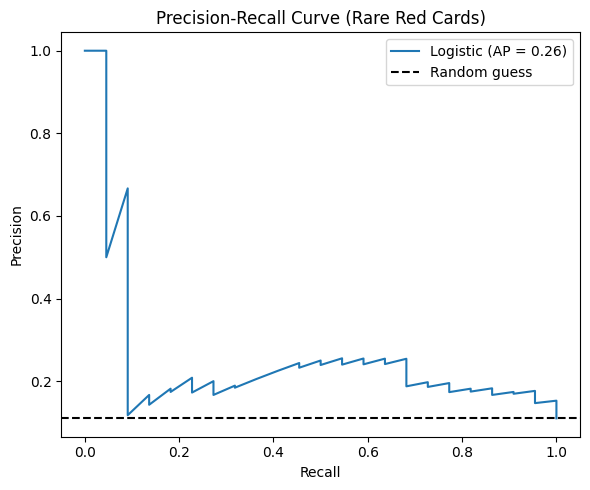

In [11]:
# Plot the PR curve
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Logistic (AP = {ap:.2f})")
plt.axhline(y2_test.mean(), color="k", linestyle="--", label="Random guess")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Rare Red Cards)")
plt.legend()
plt.tight_layout()
plt.savefig("images/precision_recall_curve.png", dpi=150)
plt.show()

## Practice Exercise
Train a `RandomForestClassifier` on the `red_card` target. Does its ROC AUC beat logistic regression? Does its Average Precision?

In [12]:
# Your turn: Random Forest on the rare red_card target
forest2 = RandomForestClassifier(n_estimators=100, random_state=42)
forest2.fit(X2_train, y2_train)
p_forest2 = forest2.predict_proba(X2_test)[:, 1]
print("Forest ROC AUC:", round(roc_auc_score(y2_test, p_forest2), 3))
print("Forest AP:     ", round(average_precision_score(y2_test, p_forest2), 3))

Forest ROC AUC: 0.727
Forest AP:      0.244


## Mini Challenge
Find the threshold on the win model that gives a TPR of at least 0.80 with the lowest FPR.

In [13]:
# Keep only thresholds where TPR >= 0.80, then take the one with the lowest FPR
good = table[table["tpr"] >= 0.80]
best = good.sort_values("fpr").iloc[0]
print(best.round(3))

threshold    0.533
fpr          0.357
tpr          0.802
Name: 38, dtype: float64


## Summary
- ROC curve = TPR vs FPR across all thresholds
- AUC: 0.5 is random, 1.0 is perfect, 0.7+ is generally useful
- Use `predict_proba`, not `predict`, for ROC and AUC
- AUC does not depend on the 0.5 cutoff
- For rare positives, check the Precision-Recall curve too